In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# --------------------------------------------------
# Paths
# --------------------------------------------------

DATA_DIR = Path(
    "/Users/neda/Documents/Projects/2027_ICPhS (2)/data"
)

In [32]:
# Hand-crafted representations
df_rhythm = pd.read_csv(
    DATA_DIR / "df_rhythm_persian.csv"
)

df_egemaps = pd.read_csv(
    DATA_DIR / "persian_egemaps_features.csv"
)

# Learned representations: XLSR-53, layers 3–24
xlsr_layers = [3, 6, 9, 12, 15, 18, 21, 24]

df_xlsr = {
    layer: pd.read_csv(
        DATA_DIR / f"persian_wav2vec2_xlsr53_L{layer:02d}.csv"
    )
    for layer in xlsr_layers
}

In [34]:
# --------------------------------------------------
# Harmonize speaker IDs
# --------------------------------------------------

# Rhythm already uses IDs such as P01, P02, ..., P30
df_rhythm["speaker_id"] = df_rhythm["Speaker"]

# eGeMAPS: extract final two digits from IDs such as P_1984_F_22
df_egemaps["speaker_id"] = (
    "P" + df_egemaps["speaker"].str.extract(r"_(\d{2})$")[0]
)

# XLSR: same speaker-ID structure as eGeMAPS
for layer, df in df_xlsr.items():
    df["speaker_id"] = (
        "P" + df["speaker"].str.extract(r"_(\d{2})$")[0]
    )


# --------------------------------------------------
# Define metadata columns
# --------------------------------------------------

rhythm_metadata = [
    "File_Name",
    "Language",
    "Speaker",
    "Year_of_Birth",
    "Age",
    "Gender",
    "ID",
    "Task",
    "speaker_id",
]

egemaps_metadata = [
    "speaker",
    "task",
    "file",
    "feature_set",
    "feature_level",
    "speaker_id",
]

xlsr_metadata = [
    "file",
    "start",
    "end",
    "speaker",
    "task",
    "speaker_id",
]


# --------------------------------------------------
# Define feature columns
# --------------------------------------------------

rhythm_features = [
    col for col in df_rhythm.columns
    if col not in rhythm_metadata
]

egemaps_features = [
    col for col in df_egemaps.columns
    if col not in egemaps_metadata
]

# Explicitly select learned embedding dimensions for each layer
xlsr_features_by_layer = {
    layer: [
        col for col in df.columns
        if col.startswith("feat_")
    ]
    for layer, df in df_xlsr.items()
}

# Check that all XLSR layers contain the same embedding dimensions
reference_features = xlsr_features_by_layer[xlsr_layers[0]]

assert all(
    features == reference_features
    for features in xlsr_features_by_layer.values()
), "XLSR feature columns differ across layers."

# All layers share the same feature columns
xlsr_features = reference_features


# --------------------------------------------------
# Check feature dimensions
# --------------------------------------------------

print("Feature dimensions")
print("------------------")
print(f"Rhythm:  {len(rhythm_features)}")
print(f"eGeMAPS: {len(egemaps_features)}")

for layer in xlsr_layers:
    print(
        f"XLSR L{layer:02d}: "
        f"{len(xlsr_features_by_layer[layer])}"
    )

Feature dimensions
------------------
Rhythm:  28
eGeMAPS: 88
XLSR L03: 1024
XLSR L06: 1024
XLSR L09: 1024
XLSR L12: 1024
XLSR L15: 1024
XLSR L18: 1024
XLSR L21: 1024
XLSR L24: 1024


In [35]:
# --------------------------------------------------
# Inspect speaker/task metadata
# --------------------------------------------------

print("Rhythm")
print(df_rhythm[["speaker_id", "Task"]].head())

print("\neGeMAPS")
print(df_egemaps[["speaker_id", "task"]].head())

for layer in xlsr_layers:
    print(f"\nXLSR L{layer:02d}")
    print(df_xlsr[layer][["speaker_id", "task"]].head())

Rhythm
  speaker_id  Task
0        P22  m(f)
1        P22  m(i)
2        P22  r(f)
3        P22  r(i)
4        P22   con

eGeMAPS
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L03
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L06
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L09
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L12
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L15
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L18
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)

XLSR L21
  

In [36]:
# --------------------------------------------------
# Check speaker-task coverage across representations
# --------------------------------------------------

rhythm_pairs = set(
    zip(df_rhythm["speaker_id"], df_rhythm["Task"])
)

egemaps_pairs = set(
    zip(df_egemaps["speaker_id"], df_egemaps["task"])
)

assert rhythm_pairs == egemaps_pairs, \
    "Rhythm and eGeMAPS speaker-task pairs differ."

for layer in xlsr_layers:
    xlsr_pairs = set(
        zip(df_xlsr[layer]["speaker_id"], df_xlsr[layer]["task"])
    )

    assert rhythm_pairs == xlsr_pairs, \
        f"Rhythm and XLSR L{layer:02d} speaker-task pairs differ."

# Also check that each speaker-task combination occurs exactly once
assert not df_rhythm.duplicated(["speaker_id", "Task"]).any()
assert not df_egemaps.duplicated(["speaker_id", "task"]).any()

for layer in xlsr_layers:
    assert not df_xlsr[layer].duplicated(
        ["speaker_id", "task"]
    ).any(), f"Duplicate speaker-task rows in XLSR L{layer:02d}."

print("All representations contain identical speaker-task pairs.")
print(f"Speakers: {df_rhythm['speaker_id'].nunique()}")
print(f"Speaker-task pairs: {len(rhythm_pairs)}")

All representations contain identical speaker-task pairs.
Speakers: 30
Speaker-task pairs: 210


# PCA

Run PCA for all three representations

In [37]:
# --------------------------------------------------
# PCA function: retain at least 80% of variance
# --------------------------------------------------

def fit_pca(df, feature_cols, variance_threshold=0.80):
    """
    Standardize features and perform PCA.

    Retains the minimum number of principal components
    needed to explain at least the specified proportion
    of total variance.
    """

    X = df[feature_cols].astype(float).values

    # Z-standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Full PCA
    pca = PCA()
    scores_all = pca.fit_transform(X_scaled)

    # Cumulative explained variance
    cumulative_variance = np.cumsum(
        pca.explained_variance_ratio_
    )

    # Minimum number of PCs needed to reach threshold
    n_retained = (
        np.searchsorted(
            cumulative_variance,
            variance_threshold
        ) + 1
    )

    # Actual variance explained by retained PCs
    explained_variance = cumulative_variance[
        n_retained - 1
    ]

    # Retained PC scores
    scores = pd.DataFrame(
        scores_all[:, :n_retained],
        columns=[
            f"PC{i+1}"
            for i in range(n_retained)
        ],
        index=df.index
    )

    return {
        "scaler": scaler,
        "pca": pca,
        "scores": scores,
        "eigenvalues": pca.explained_variance_,
        "n_retained": n_retained,
        "explained_variance": explained_variance,
        "variance_threshold": variance_threshold
    }

In [38]:
rhythm_pca = fit_pca(
    df_rhythm,
    rhythm_features
)

egemaps_pca = fit_pca(
    df_egemaps,
    egemaps_features
)

xlsr_pca = {
    layer: fit_pca(
        df_xlsr[layer],
        xlsr_features_by_layer[layer]
    )
    for layer in xlsr_layers
}

Inspect the PCA results

In [39]:



pca_summary = pd.DataFrame({
    "representation": (
        ["Rhythm", "eGeMAPS"] +
        [f"XLSR L{layer:02d}" for layer in xlsr_layers]
    ),

    "original_dimensions": (
        [
            len(rhythm_features),
            len(egemaps_features)
        ] +
        [
            len(xlsr_features_by_layer[layer])
            for layer in xlsr_layers
        ]
    ),

    "retained_PCs": (
        [
            rhythm_pca["n_retained"],
            egemaps_pca["n_retained"]
        ] +
        [
            xlsr_pca[layer]["n_retained"]
            for layer in xlsr_layers
        ]
    ),

    "variance_explained": (
        [
            rhythm_pca["explained_variance"],
            egemaps_pca["explained_variance"]
        ] +
        [
            xlsr_pca[layer]["explained_variance"]
            for layer in xlsr_layers
        ]
    )
})

pca_summary["variance_explained"] *= 100

print(pca_summary.to_string(index=False))

representation  original_dimensions  retained_PCs  variance_explained
        Rhythm                   28             4           80.635615
       eGeMAPS                   88            11           81.216458
      XLSR L03                 1024            19           80.724229
      XLSR L06                 1024            21           80.584416
      XLSR L09                 1024            21           80.910485
      XLSR L12                 1024            22           80.192546
      XLSR L15                 1024            18           80.408513
      XLSR L18                 1024            19           80.979550
      XLSR L21                 1024            18           80.597844
      XLSR L24                 1024             4           81.634287


# --------------------------------------------------
# Motivating visualization: Rhythm vs. eGeMAPS spaces
# --------------------------------------------------

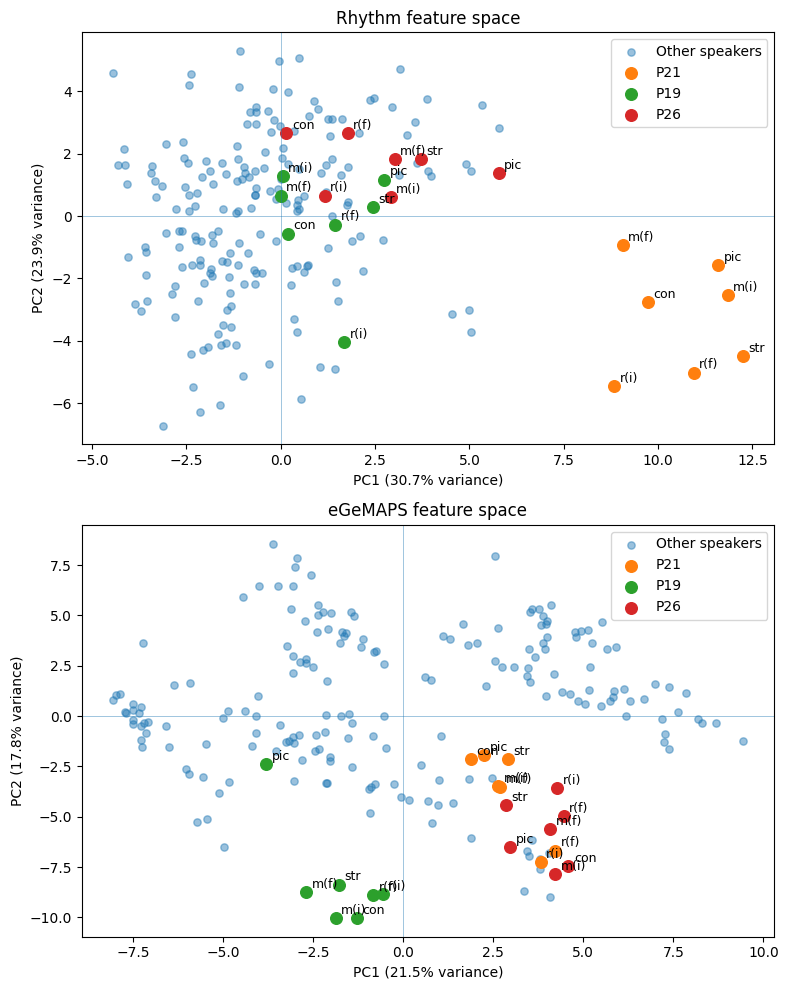

In [40]:
import matplotlib.pyplot as plt

# Exact IDs in df["speaker"] -> short labels for the figure
highlight_speakers = {
    "P_1994_M_21": "P21",
    "P_1992_F_19": "P19",
    "P_1998_F_26": "P26"
}

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

representations = [
    ("Rhythm feature space", rhythm_pca),
    ("eGeMAPS feature space", egemaps_pca)
]

for ax, (title, result) in zip(axes, representations):

    scores = result["scores"]
    variance = result["pca"].explained_variance_ratio_ * 100

    # Plot all non-highlighted speaker-task observations
    other_mask = ~df["speaker"].isin(highlight_speakers.keys())

    ax.scatter(
        scores.loc[other_mask, "PC1"],
        scores.loc[other_mask, "PC2"],
        s=28,
        alpha=0.45,
        label="Other speakers"
    )

    # Plot and label the three highlighted speakers
    for speaker_id, short_label in highlight_speakers.items():

        mask = df["speaker"] == speaker_id

        ax.scatter(
            scores.loc[mask, "PC1"],
            scores.loc[mask, "PC2"],
            s=70,
            label=short_label
        )

        # Label each of the seven tasks
        for idx in df.index[mask]:
            ax.annotate(
                df.loc[idx, "task"],
                (
                    scores.loc[idx, "PC1"],
                    scores.loc[idx, "PC2"]
                ),
                xytext=(4, 3),
                textcoords="offset points",
                fontsize=9
            )

    ax.axhline(0, linewidth=0.6, alpha=0.5)
    ax.axvline(0, linewidth=0.6, alpha=0.5)

    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({variance[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({variance[1]:.1f}% variance)")
    ax.legend()

plt.tight_layout()

fig.savefig(
    "PCA_rhythm_eGeMAPS_vertical.pdf",
    bbox_inches="tight"
)

plt.show()

# BETWEEN-SPEAKER RSA

Function to construct a speaker RDM

In [41]:
def speaker_rdm(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Construct a speaker-by-speaker representational
    dissimilarity matrix (RDM).

    1. Use retained PCA scores.
    2. Center observations within task.
    3. Calculate one centroid per speaker.
    4. Calculate pairwise Euclidean distances
       among speaker centroids.
    """

    if k is None:
        k = pca_result["n_retained"]

    pc_cols = [
        f"PC{i+1}"
        for i in range(k)
    ]

    scores = pca_result["scores"][pc_cols].copy()

    scores["speaker"] = df[speaker_col].values
    scores["task"] = df[task_col].values

    # -------------------------
    # Task centering
    # -------------------------

    task_means = (
        scores
        .groupby("task")[pc_cols]
        .transform("mean")
    )

    scores[pc_cols] = (
        scores[pc_cols] - task_means
    )

    # -------------------------
    # Speaker centroids
    # -------------------------

    speaker_centroids = (
        scores
        .groupby("speaker")[pc_cols]
        .mean()
        .sort_index()
    )

    # -------------------------
    # Pairwise distances
    # -------------------------

    distances = squareform(
        pdist(
            speaker_centroids.values,
            metric="euclidean"
        )
    )

    rdm = pd.DataFrame(
        distances,
        index=speaker_centroids.index,
        columns=speaker_centroids.index
    )

    return speaker_centroids, rdm

In [42]:
rhythm_centroids, rhythm_rdm = speaker_rdm(
    df=df_rhythm,
    pca_result=rhythm_pca,
    speaker_col="speaker_id",
    task_col="Task"
)

egemaps_centroids, egemaps_rdm = speaker_rdm(
    df=df_egemaps,
    pca_result=egemaps_pca,
    speaker_col="speaker_id",
    task_col="task"
)

# XLSR-53: all selected layers
xlsr_centroids = {}
xlsr_rdms = {}

for layer in xlsr_layers:
    xlsr_centroids[layer], xlsr_rdms[layer] = speaker_rdm(
        df=df_xlsr[layer],
        pca_result=xlsr_pca[layer],
        speaker_col="speaker_id",
        task_col="task"
    )

Check the RDMs

In [43]:
# --------------------------------------------------
# Check RDM dimensions
# --------------------------------------------------

print("RDM dimensions")
print("--------------")

print("Rhythm: ", rhythm_rdm.shape)
print("eGeMAPS:", egemaps_rdm.shape)

for layer in xlsr_layers:
    print(
        f"XLSR L{layer:02d}:",
        xlsr_rdms[layer].shape
    )

# Inspect part of one RDM
print("\nRhythm RDM:")
print(rhythm_rdm.iloc[:5, :5])


# Verify identical speaker labels across all RDMs
reference_speakers = rhythm_rdm.index.tolist()

assert egemaps_rdm.index.tolist() == reference_speakers

for layer in xlsr_layers:
    assert xlsr_rdms[layer].index.tolist() == reference_speakers, \
        f"Speaker ordering differs in XLSR L{layer:02d}"

print("\nAll RDMs contain the same 30 speakers in the same order.")

RDM dimensions
--------------
Rhythm:  (30, 30)
eGeMAPS: (30, 30)
XLSR L03: (30, 30)
XLSR L06: (30, 30)
XLSR L09: (30, 30)
XLSR L12: (30, 30)
XLSR L15: (30, 30)
XLSR L18: (30, 30)
XLSR L21: (30, 30)
XLSR L24: (30, 30)

Rhythm RDM:
speaker       P01       P02       P03       P04       P05
speaker                                                  
P01      0.000000  4.464757  3.484321  4.917706  4.409646
P02      4.464757  0.000000  4.386755  4.227840  3.360545
P03      3.484321  4.386755  0.000000  2.736728  3.036264
P04      4.917706  4.227840  2.736728  0.000000  2.676659
P05      4.409646  3.360545  3.036264  2.676659  0.000000

All RDMs contain the same 30 speakers in the same order.


RSA COMPARISON

Function for comparing two RDMs

This calculates Spearman correlation across the 435 unique speaker pairs.

In [44]:
def compare_rdms(
    rdm1,
    rdm2,
    n_permutations=10000,
    seed=42
):
    """
    Compare two speaker RDMs using Spearman correlation
    and a speaker-label permutation test.
    """

    # Same speakers in both matrices
    common = sorted(
        set(rdm1.index) &
        set(rdm2.index)
    )

    A = rdm1.loc[common, common].values
    B = rdm2.loc[common, common].values

    n = len(common)

    # Upper triangle:
    # 30 speakers -> 435 unique pairs
    upper = np.triu_indices(n, k=1)

    x = A[upper]
    y = B[upper]

    # -------------------------
    # Observed RSA
    # -------------------------

    observed_rho, _ = spearmanr(x, y)

    # -------------------------
    # Permutation inference
    # -------------------------

    rng = np.random.default_rng(seed)

    permutation_rhos = np.empty(
        n_permutations
    )

    for i in range(n_permutations):

        perm = rng.permutation(n)

        # Permute rows and columns together
        B_perm = B[np.ix_(perm, perm)]

        y_perm = B_perm[upper]

        permutation_rhos[i], _ = spearmanr(
            x,
            y_perm
        )

    # Two-sided permutation p-value
    p_value = (
        np.sum(
            np.abs(permutation_rhos)
            >= np.abs(observed_rho)
        ) + 1
    ) / (n_permutations + 1)

    return {
        "rho": observed_rho,
        "p": p_value,
        "n_speakers": n,
        "n_pairs": len(x),
        "permutation_rhos": permutation_rhos
    }

Rhythm vs eGeMAPS

In [45]:
# --------------------------------------------------
# RSA comparisons
# --------------------------------------------------

# Hand-crafted representations
rsa_rhythm_egemaps = compare_rdms(
    rhythm_rdm,
    egemaps_rdm,
    n_permutations=10000,
    seed=42
)

# Each hand-crafted representation vs each XLSR layer
rsa_results = []

# Rhythm vs eGeMAPS
rsa_results.append({
    "representation_1": "Rhythm",
    "representation_2": "eGeMAPS",
    "layer": np.nan,
    **rsa_rhythm_egemaps
})

# Rhythm / eGeMAPS vs XLSR layers
for layer in xlsr_layers:

    rsa_rhythm_xlsr = compare_rdms(
        rhythm_rdm,
        xlsr_rdms[layer],
        n_permutations=10000,
        seed=42
    )

    rsa_egemaps_xlsr = compare_rdms(
        egemaps_rdm,
        xlsr_rdms[layer],
        n_permutations=10000,
        seed=42
    )

    rsa_results.append({
        "representation_1": "Rhythm",
        "representation_2": f"XLSR L{layer:02d}",
        "layer": layer,
        **rsa_rhythm_xlsr
    })

    rsa_results.append({
        "representation_1": "eGeMAPS",
        "representation_2": f"XLSR L{layer:02d}",
        "layer": layer,
        **rsa_egemaps_xlsr
    })


# --------------------------------------------------
# Results table
# --------------------------------------------------

rsa_results = pd.DataFrame(rsa_results)

print(
    rsa_results[
        [
            "representation_1",
            "representation_2",
            "rho",
            "p",
            "n_pairs"
        ]
    ].to_string(index=False)
)

representation_1 representation_2      rho        p  n_pairs
          Rhythm          eGeMAPS 0.434177 0.000100      435
          Rhythm         XLSR L03 0.409607 0.000300      435
         eGeMAPS         XLSR L03 0.827685 0.000100      435
          Rhythm         XLSR L06 0.450884 0.000200      435
         eGeMAPS         XLSR L06 0.701992 0.000100      435
          Rhythm         XLSR L09 0.466408 0.000100      435
         eGeMAPS         XLSR L09 0.629116 0.000100      435
          Rhythm         XLSR L12 0.514397 0.000100      435
         eGeMAPS         XLSR L12 0.627230 0.000100      435
          Rhythm         XLSR L15 0.510590 0.000100      435
         eGeMAPS         XLSR L15 0.645803 0.000100      435
          Rhythm         XLSR L18 0.444409 0.000100      435
         eGeMAPS         XLSR L18 0.726590 0.000100      435
          Rhythm         XLSR L21 0.394970 0.000100      435
         eGeMAPS         XLSR L21 0.716363 0.000100      435
          Rhythm        

Print dimensionality information beside the RSA results

In [46]:
# --------------------------------------------------
# Print full RSA results
# --------------------------------------------------

print("Rhythm – eGeMAPS")
print(f"rho = {rsa_rhythm_egemaps['rho']:.4f}")
print(f"p   = {rsa_rhythm_egemaps['p']:.6f}")
print()

for layer in xlsr_layers:
    rhythm_result = rsa_results[
        (rsa_results["representation_1"] == "Rhythm") &
        (rsa_results["layer"] == layer)
    ].iloc[0]

    egemaps_result = rsa_results[
        (rsa_results["representation_1"] == "eGeMAPS") &
        (rsa_results["layer"] == layer)
    ].iloc[0]

    print(f"Rhythm – XLSR L{layer:02d}")
    print(f"rho = {rhythm_result['rho']:.4f}")
    print(f"p   = {rhythm_result['p']:.6f}")
    print()

    print(f"eGeMAPS – XLSR L{layer:02d}")
    print(f"rho = {egemaps_result['rho']:.4f}")
    print(f"p   = {egemaps_result['p']:.6f}")
    print()

    print(
    rsa_results[
        [
            "representation_1",
            "representation_2",
            "rho",
            "p",
            "n_pairs"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Rhythm – eGeMAPS
rho = 0.4342
p   = 0.000100

Rhythm – XLSR L03
rho = 0.4096
p   = 0.000300

eGeMAPS – XLSR L03
rho = 0.8277
p   = 0.000100

representation_1 representation_2    rho      p  n_pairs
          Rhythm          eGeMAPS 0.4342 0.0001      435
          Rhythm         XLSR L03 0.4096 0.0003      435
         eGeMAPS         XLSR L03 0.8277 0.0001      435
          Rhythm         XLSR L06 0.4509 0.0002      435
         eGeMAPS         XLSR L06 0.7020 0.0001      435
          Rhythm         XLSR L09 0.4664 0.0001      435
         eGeMAPS         XLSR L09 0.6291 0.0001      435
          Rhythm         XLSR L12 0.5144 0.0001      435
         eGeMAPS         XLSR L12 0.6272 0.0001      435
          Rhythm         XLSR L15 0.5106 0.0001      435
         eGeMAPS         XLSR L15 0.6458 0.0001      435
          Rhythm         XLSR L18 0.4444 0.0001      435
         eGeMAPS         XLSR L18 0.7266 0.0001      435
          Rhythm         XLSR L21 0.3950 0.0001      435
    

In [47]:
from statsmodels.stats.multitest import multipletests

rsa_results["p_fdr"] = np.nan

for representation in ["Rhythm", "eGeMAPS"]:

    mask = (
        (rsa_results["representation_1"] == representation) &
        (rsa_results["layer"].notna())
    )

    _, p_fdr, _, _ = multipletests(
        rsa_results.loc[mask, "p"].values,
        alpha=0.05,
        method="fdr_bh"
    )

    rsa_results.loc[mask, "p_fdr"] = p_fdr

print(
    rsa_results[
        [
            "representation_1",
            "representation_2",
            "rho",
            "p",
            "p_fdr"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

representation_1 representation_2    rho      p  p_fdr
          Rhythm          eGeMAPS 0.4342 0.0001    NaN
          Rhythm         XLSR L03 0.4096 0.0003 0.0003
         eGeMAPS         XLSR L03 0.8277 0.0001 0.0001
          Rhythm         XLSR L06 0.4509 0.0002 0.0003
         eGeMAPS         XLSR L06 0.7020 0.0001 0.0001
          Rhythm         XLSR L09 0.4664 0.0001 0.0002
         eGeMAPS         XLSR L09 0.6291 0.0001 0.0001
          Rhythm         XLSR L12 0.5144 0.0001 0.0002
         eGeMAPS         XLSR L12 0.6272 0.0001 0.0001
          Rhythm         XLSR L15 0.5106 0.0001 0.0002
         eGeMAPS         XLSR L15 0.6458 0.0001 0.0001
          Rhythm         XLSR L18 0.4444 0.0001 0.0002
         eGeMAPS         XLSR L18 0.7266 0.0001 0.0001
          Rhythm         XLSR L21 0.3950 0.0001 0.0002
         eGeMAPS         XLSR L21 0.7164 0.0001 0.0001
          Rhythm         XLSR L24 0.2782 0.0148 0.0148
         eGeMAPS         XLSR L24 0.4396 0.0002 0.0002


# --------------------------------------------------
# Within and betweeen-speaker task dispersion
# --------------------------------------------------

In [48]:
# ==================================================
# WITHIN- AND BETWEEN-SPEAKER VARIABILITY
# ==================================================

import numpy as np
import pandas as pd

from scipy.spatial.distance import mahalanobis


# ==================================================
# 1. Within-speaker task variability
# ==================================================

def within_speaker_dispersion(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Quantify within-speaker task variability as the mean
    Euclidean distance of a speaker's seven task recordings
    from that speaker's centroid in the retained PCA space.
    """

    if k is None:
        k = pca_result["n_retained"]

    scores = (
        pca_result["scores"]
        .iloc[:, :k]
        .to_numpy()
    )

    score_cols = [
        f"PC{i+1}"
        for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # Speaker-specific centroids
    speaker_centroids = (
        score_df
        .groupby("speaker_id")[score_cols]
        .transform("mean")
    )

    deviations = (
        score_df[score_cols]
        - speaker_centroids
    )

    score_df["within_distance"] = np.sqrt(
        np.sum(
            deviations.to_numpy() ** 2,
            axis=1
        )
    )

    # Speaker-level summary
    speaker_summary = (
        score_df
        .groupby("speaker_id")["within_distance"]
        .agg(
            mean_within_distance="mean",
            median_within_distance="median",
            sd_within_distance="std",
            min_within_distance="min",
            max_within_distance="max"
        )
        .reset_index()
    )

    # Rank 1 = greatest within-speaker variability
    speaker_summary["within_rank"] = (
        speaker_summary["mean_within_distance"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    speaker_summary = (
        speaker_summary
        .sort_values("within_rank")
        .reset_index(drop=True)
    )

    return score_df, speaker_summary


# --------------------------------------------------
# Run within-speaker analyses
# --------------------------------------------------

rhythm_within, rhythm_speaker_within = (
    within_speaker_dispersion(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)

egemaps_within, egemaps_speaker_within = (
    within_speaker_dispersion(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)

xlsr_within = {}
xlsr_speaker_within = {}

for layer in xlsr_layers:
    (
        xlsr_within[layer],
        xlsr_speaker_within[layer]
    ) = within_speaker_dispersion(
        df=df_xlsr[layer],
        pca_result=xlsr_pca[layer],
        speaker_col="speaker_id",
        task_col="task"
    )


# ==================================================
# 2. Between-speaker peripherality
# ==================================================

def between_speaker_peripherality(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Quantify between-speaker peripherality using
    task-conditioned Mahalanobis distance.

    Each recording is compared with the population centroid
    for the corresponding speaking task. A common covariance
    matrix is estimated from all task-centered observations.
    """

    if k is None:
        k = pca_result["n_retained"]

    scores = (
        pca_result["scores"]
        .iloc[:, :k]
        .to_numpy()
    )

    score_cols = [
        f"PC{i+1}"
        for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # Task-specific population centroids
    task_centroids = (
        score_df
        .groupby("task")[score_cols]
        .transform("mean")
    )

    centered_scores = (
        score_df[score_cols]
        - task_centroids
    )

    # Common covariance matrix
    covariance = np.cov(
        centered_scores.to_numpy(),
        rowvar=False
    )

    inverse_covariance = np.linalg.pinv(
        covariance
    )

    # After task centering, the task-specific
    # population centroid is the zero vector
    zero = np.zeros(k)

    score_df["between_distance"] = [
        mahalanobis(
            row,
            zero,
            inverse_covariance
        )
        for row in centered_scores.to_numpy()
    ]

    # Speaker-level summary
    speaker_summary = (
        score_df
        .groupby("speaker_id")["between_distance"]
        .agg(
            mean_between_distance="mean",
            median_between_distance="median",
            sd_between_distance="std",
            min_between_distance="min",
            max_between_distance="max"
        )
        .reset_index()
    )

    # Rank 1 = most peripheral speaker
    speaker_summary["between_rank"] = (
        speaker_summary["mean_between_distance"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    speaker_summary = (
        speaker_summary
        .sort_values("between_rank")
        .reset_index(drop=True)
    )

    return score_df, speaker_summary


# --------------------------------------------------
# Run between-speaker analyses
# --------------------------------------------------

rhythm_between, rhythm_speaker_between = (
    between_speaker_peripherality(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)

egemaps_between, egemaps_speaker_between = (
    between_speaker_peripherality(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)

xlsr_between = {}
xlsr_speaker_between = {}

for layer in xlsr_layers:
    (
        xlsr_between[layer],
        xlsr_speaker_between[layer]
    ) = between_speaker_peripherality(
        df=df_xlsr[layer],
        pca_result=xlsr_pca[layer],
        speaker_col="speaker_id",
        task_col="task"
    )


# ==================================================
# 3. Checks
# ==================================================

print("\n" + "=" * 60)
print("PCA DIMENSIONS USED")
print("=" * 60)

print(
    f"Rhythm:   {rhythm_pca['n_retained']:2d} PCs "
    f"({rhythm_pca['explained_variance'] * 100:.1f}% variance)"
)

print(
    f"eGeMAPS:  {egemaps_pca['n_retained']:2d} PCs "
    f"({egemaps_pca['explained_variance'] * 100:.1f}% variance)"
)

for layer in xlsr_layers:
    print(
        f"XLSR L{layer:02d}: "
        f"{xlsr_pca[layer]['n_retained']:2d} PCs "
        f"({xlsr_pca[layer]['explained_variance'] * 100:.1f}% variance)"
    )


print("\n" + "=" * 60)
print("NUMBER OF SPEAKERS")
print("=" * 60)

print(
    "Rhythm:  ",
    len(rhythm_speaker_within)
)

print(
    "eGeMAPS: ",
    len(egemaps_speaker_within)
)

for layer in xlsr_layers:
    print(
        f"XLSR L{layer:02d}:",
        len(xlsr_speaker_within[layer])
    )


PCA DIMENSIONS USED
Rhythm:    4 PCs (80.6% variance)
eGeMAPS:  11 PCs (81.2% variance)
XLSR L03: 19 PCs (80.7% variance)
XLSR L06: 21 PCs (80.6% variance)
XLSR L09: 21 PCs (80.9% variance)
XLSR L12: 22 PCs (80.2% variance)
XLSR L15: 18 PCs (80.4% variance)
XLSR L18: 19 PCs (81.0% variance)
XLSR L21: 18 PCs (80.6% variance)
XLSR L24:  4 PCs (81.6% variance)

NUMBER OF SPEAKERS
Rhythm:   30
eGeMAPS:  30
XLSR L03: 30
XLSR L06: 30
XLSR L09: 30
XLSR L12: 30
XLSR L15: 30
XLSR L18: 30
XLSR L21: 30
XLSR L24: 30


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.

In [49]:
print("\nTop 5 speakers: within-speaker task variability")

print("\nRhythm")
print(
    rhythm_speaker_within[
        ["speaker_id", "mean_within_distance", "within_rank"]
    ].head()
)

print("\neGeMAPS")
print(
    egemaps_speaker_within[
        ["speaker_id", "mean_within_distance", "within_rank"]
    ].head()
)

for layer in xlsr_layers:
    print(f"\nXLSR L{layer:02d}")
    print(
        xlsr_speaker_within[layer][
            ["speaker_id", "mean_within_distance", "within_rank"]
        ].head()
    )


Top 5 speakers: within-speaker task variability

Rhythm
  speaker_id  mean_within_distance  within_rank
0        P12              3.855784            1
1        P30              3.571242            2
2        P11              3.250224            3
3        P20              3.150305            4
4        P16              3.146594            5

eGeMAPS
  speaker_id  mean_within_distance  within_rank
0        P18              4.364022            1
1        P19              4.232599            2
2        P26              4.222879            3
3        P05              4.178806            4
4        P03              4.153412            5

XLSR L03
  speaker_id  mean_within_distance  within_rank
0        P05             12.041991            1
1        P25             11.055774            2
2        P01             10.250864            3
3        P18             10.180424            4
4        P03             10.019424            5

XLSR L06
  speaker_id  mean_within_distance  within_rank
0 

In [50]:
print("\nTop 5 speakers: between-speaker peripherality")

print("\nRhythm")
print(
    rhythm_speaker_between[
        ["speaker_id", "mean_between_distance", "between_rank"]
    ].head()
)

print("\neGeMAPS")
print(
    egemaps_speaker_between[
        ["speaker_id", "mean_between_distance", "between_rank"]
    ].head()
)

for layer in xlsr_layers:
    print(f"\nXLSR L{layer:02d}")
    print(
        xlsr_speaker_between[layer][
            ["speaker_id", "mean_between_distance", "between_rank"]
        ].head()
    )


Top 5 speakers: between-speaker peripherality

Rhythm
  speaker_id  mean_between_distance  between_rank
0        P21               4.084916             1
1        P26               2.764857             2
2        P25               2.752370             3
3        P04               2.250794             4
4        P11               2.225360             5

eGeMAPS
  speaker_id  mean_between_distance  between_rank
0        P20               4.972848             1
1        P19               4.785212             2
2        P21               4.714240             3
3        P26               4.178439             4
4        P30               3.849119             5

XLSR L03
  speaker_id  mean_between_distance  between_rank
0        P21               5.301506             1
1        P19               5.251786             2
2        P20               5.235097             3
3        P24               5.199901             4
4        P29               5.078743             5

XLSR L06
  speaker_id  me

# ==================================================
# CROSS-REPRESENTATION STATISTICAL ANALYSIS (hand-crafted features)
# ==================================================

In [51]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd


def compare_representations(
    summary1,
    summary2,
    value_col,
    rank_col,
    name1="rep1",
    name2="rep2",
    n_permutations=10_000,
    n_bootstrap=10_000,
    seed=42
):
    """
    Compare speaker-level values between two representations.

    Returns:
        comparison_df
        results dictionary containing:
            Spearman rho
            permutation p-value
            bootstrap 95% CI
    """

    # --------------------------------------------------
    # Merge speakers across representations
    # --------------------------------------------------

    comparison = (
        summary1[
            ["speaker_id", value_col, rank_col]
        ]
        .rename(columns={
            value_col: f"{name1}_value",
            rank_col: f"{name1}_rank"
        })
        .merge(
            summary2[
                ["speaker_id", value_col, rank_col]
            ].rename(columns={
                value_col: f"{name2}_value",
                rank_col: f"{name2}_rank"
            }),
            on="speaker_id"
        )
    )

    x = comparison[f"{name1}_value"].to_numpy()
    y = comparison[f"{name2}_value"].to_numpy()

    # --------------------------------------------------
    # Observed Spearman correlation
    # --------------------------------------------------

    rho = spearmanr(x, y).statistic

    # --------------------------------------------------
    # Permutation test
    # --------------------------------------------------

    rng = np.random.default_rng(seed)

    permuted_rhos = np.empty(n_permutations)

    for i in range(n_permutations):
        permuted_rhos[i] = spearmanr(
            x,
            rng.permutation(y)
        ).statistic

    permutation_p = (
        np.sum(
            np.abs(permuted_rhos) >= np.abs(rho)
        ) + 1
    ) / (n_permutations + 1)

    # --------------------------------------------------
    # Speaker-level bootstrap confidence interval
    # --------------------------------------------------

    rng_boot = np.random.default_rng(seed)

    n_speakers = len(comparison)
    bootstrap_rhos = []

    for i in range(n_bootstrap):

        idx = rng_boot.choice(
            n_speakers,
            size=n_speakers,
            replace=True
        )

        x_boot = x[idx]
        y_boot = y[idx]

        if (
            len(np.unique(x_boot)) > 1
            and len(np.unique(y_boot)) > 1
        ):
            bootstrap_rhos.append(
                spearmanr(
                    x_boot,
                    y_boot
                ).statistic
            )

    bootstrap_rhos = np.asarray(
        bootstrap_rhos
    )

    ci_low, ci_high = np.percentile(
        bootstrap_rhos,
        [2.5, 97.5]
    )

    results = {
        "rho": rho,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "permutation_p": permutation_p,
        "n_speakers": n_speakers
    }

    return comparison, results

In [52]:
# ==================================================
# Rhythm vs eGeMAPS
# ==================================================

within_comparison, within_stats = (
    compare_representations(
        summary1=rhythm_speaker_within,
        summary2=egemaps_speaker_within,
        value_col="mean_within_distance",
        rank_col="within_rank",
        name1="rhythm",
        name2="egemaps"
    )
)

between_comparison, between_stats = (
    compare_representations(
        summary1=rhythm_speaker_between,
        summary2=egemaps_speaker_between,
        value_col="mean_between_distance",
        rank_col="between_rank",
        name1="rhythm",
        name2="egemaps"
    )
)

In [53]:
# ==================================================
# Layer-wise comparisons with XLSR
# ==================================================

within_results = []
between_results = []


for layer in xlsr_layers:

    # --------------------------------------------------
    # WITHIN: Rhythm vs XLSR
    # --------------------------------------------------

    _, stats = compare_representations(
        summary1=rhythm_speaker_within,
        summary2=xlsr_speaker_within[layer],
        value_col="mean_within_distance",
        rank_col="within_rank",
        name1="rhythm",
        name2=f"xlsr_L{layer:02d}"
    )

    within_results.append({
        "reference": "Rhythm",
        "layer": layer,
        **stats
    })


    # --------------------------------------------------
    # WITHIN: eGeMAPS vs XLSR
    # --------------------------------------------------

    _, stats = compare_representations(
        summary1=egemaps_speaker_within,
        summary2=xlsr_speaker_within[layer],
        value_col="mean_within_distance",
        rank_col="within_rank",
        name1="egemaps",
        name2=f"xlsr_L{layer:02d}"
    )

    within_results.append({
        "reference": "eGeMAPS",
        "layer": layer,
        **stats
    })


    # --------------------------------------------------
    # BETWEEN: Rhythm vs XLSR
    # --------------------------------------------------

    _, stats = compare_representations(
        summary1=rhythm_speaker_between,
        summary2=xlsr_speaker_between[layer],
        value_col="mean_between_distance",
        rank_col="between_rank",
        name1="rhythm",
        name2=f"xlsr_L{layer:02d}"
    )

    between_results.append({
        "reference": "Rhythm",
        "layer": layer,
        **stats
    })


    # --------------------------------------------------
    # BETWEEN: eGeMAPS vs XLSR
    # --------------------------------------------------

    _, stats = compare_representations(
        summary1=egemaps_speaker_between,
        summary2=xlsr_speaker_between[layer],
        value_col="mean_between_distance",
        rank_col="between_rank",
        name1="egemaps",
        name2=f"xlsr_L{layer:02d}"
    )

    between_results.append({
        "reference": "eGeMAPS",
        "layer": layer,
        **stats
    })


within_results = pd.DataFrame(within_results)
between_results = pd.DataFrame(between_results)

In [54]:
# ==================================================
# Rank-comparison plotting function
# ==================================================

import matplotlib.pyplot as plt


def plot_rank_comparison(
    comparison,
    xlabel,
    ylabel,
    title=None,
    save_path=None
):
    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    ax.scatter(
        comparison["rhythm_rank"],
        comparison["egemaps_rank"],
        s=35
    )

    # Identical-rank reference line
    ax.plot(
        [1, 30],
        [1, 30],
        linestyle="--",
        linewidth=0.8
    )

    # Speaker labels
    for _, row in comparison.iterrows():
        ax.annotate(
            row["speaker_id"],
            (
                row["rhythm_rank"],
                row["egemaps_rank"]
            ),
            fontsize=7,
            xytext=(3, 3),
            textcoords="offset points"
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rank 1 = highest variability/peripherality
    ax.set_xlim(30.5, 0.5)
    ax.set_ylim(30.5, 0.5)

    ax.set_xticks(
        [30, 25, 20, 15, 10, 5, 1]
    )

    ax.set_yticks(
        [30, 25, 20, 15, 10, 5, 1]
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            bbox_inches="tight"
        )

    plt.show()


within_results_df = pd.DataFrame(within_results)
between_results_df = pd.DataFrame(between_results)

print(within_results_df.shape)
print(between_results_df.shape)

(16, 7)
(16, 7)


In [55]:
print("\nWITHIN-SPEAKER TASK VARIABILITY")
print(
    within_results_df[
        [
            "reference",
            "layer",
            "rho",
            "ci_low",
            "ci_high",
            "permutation_p"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print("\nBETWEEN-SPEAKER PERIPHERALITY")
print(
    between_results_df[
        [
            "reference",
            "layer",
            "rho",
            "ci_low",
            "ci_high",
            "permutation_p"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)


WITHIN-SPEAKER TASK VARIABILITY
reference  layer    rho  ci_low  ci_high  permutation_p
   Rhythm      3  0.141  -0.206    0.467          0.452
  eGeMAPS      3  0.620   0.280    0.871          0.001
   Rhythm      6  0.291  -0.076    0.600          0.117
  eGeMAPS      6  0.636   0.311    0.843          0.000
   Rhythm      9  0.272  -0.109    0.601          0.143
  eGeMAPS      9  0.587   0.249    0.822          0.000
   Rhythm     12  0.253  -0.143    0.611          0.175
  eGeMAPS     12  0.496   0.145    0.769          0.006
   Rhythm     15  0.262  -0.128    0.606          0.163
  eGeMAPS     15  0.565   0.214    0.821          0.001
   Rhythm     18  0.171  -0.217    0.527          0.369
  eGeMAPS     18  0.542   0.186    0.809          0.002
   Rhythm     21  0.186  -0.178    0.516          0.320
  eGeMAPS     21  0.666   0.379    0.845          0.000
   Rhythm     24 -0.106  -0.450    0.237          0.574
  eGeMAPS     24 -0.196  -0.484    0.153          0.301

BETWEEN-SPEAKE

Plotting

In [56]:
from statsmodels.stats.multitest import multipletests

for results_df in [
    within_results_df,
    between_results_df
]:
    results_df["p_fdr"] = np.nan

    for reference in ["Rhythm", "eGeMAPS"]:

        mask = (
            results_df["reference"] == reference
        )

        _, p_fdr, _, _ = multipletests(
            results_df.loc[
                mask,
                "permutation_p"
            ].values,
            alpha=0.05,
            method="fdr_bh"
        )

        results_df.loc[
            mask,
            "p_fdr"
        ] = p_fdr

In [57]:
print("\nWITHIN-SPEAKER TASK VARIABILITY")
print(
    within_results_df[
        [
            "reference",
            "layer",
            "rho",
            "ci_low",
            "ci_high",
            "permutation_p",
            "p_fdr"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print("\nBETWEEN-SPEAKER PERIPHERALITY")
print(
    between_results_df[
        [
            "reference",
            "layer",
            "rho",
            "ci_low",
            "ci_high",
            "permutation_p",
            "p_fdr"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)


WITHIN-SPEAKER TASK VARIABILITY
reference  layer    rho  ci_low  ci_high  permutation_p  p_fdr
   Rhythm      3  0.141  -0.206    0.467          0.452  0.517
  eGeMAPS      3  0.620   0.280    0.871          0.001  0.001
   Rhythm      6  0.291  -0.076    0.600          0.117  0.351
  eGeMAPS      6  0.636   0.311    0.843          0.000  0.001
   Rhythm      9  0.272  -0.109    0.601          0.143  0.351
  eGeMAPS      9  0.587   0.249    0.822          0.000  0.001
   Rhythm     12  0.253  -0.143    0.611          0.175  0.351
  eGeMAPS     12  0.496   0.145    0.769          0.006  0.006
   Rhythm     15  0.262  -0.128    0.606          0.163  0.351
  eGeMAPS     15  0.565   0.214    0.821          0.001  0.001
   Rhythm     18  0.171  -0.217    0.527          0.369  0.492
  eGeMAPS     18  0.542   0.186    0.809          0.002  0.003
   Rhythm     21  0.186  -0.178    0.516          0.320  0.492
  eGeMAPS     21  0.666   0.379    0.845          0.000  0.001
   Rhythm     24 -0.10

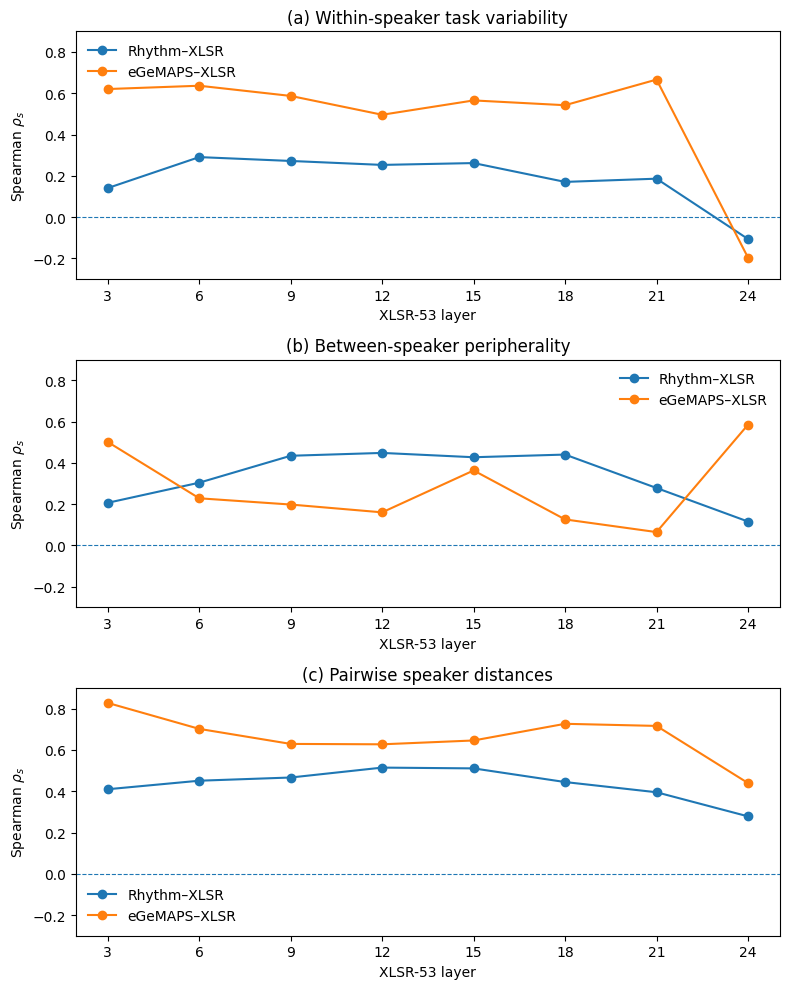

In [58]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare results
# ------------------------------------------------------------

within_rhythm = (
    within_results_df[within_results_df["reference"] == "Rhythm"]
    .sort_values("layer")
)
within_egemaps = (
    within_results_df[within_results_df["reference"] == "eGeMAPS"]
    .sort_values("layer")
)

between_rhythm = (
    between_results_df[between_results_df["reference"] == "Rhythm"]
    .sort_values("layer")
)
between_egemaps = (
    between_results_df[between_results_df["reference"] == "eGeMAPS"]
    .sort_values("layer")
)

rsa_rhythm = (
    rsa_results[
        (rsa_results["representation_1"] == "Rhythm") &
        (rsa_results["layer"].notna())
    ]
    .sort_values("layer")
)

rsa_egemaps = (
    rsa_results[
        (rsa_results["representation_1"] == "eGeMAPS") &
        (rsa_results["layer"].notna())
    ]
    .sort_values("layer")
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 10),
    sharex=False,   # show x tick labels on every panel
    sharey=True
)

panels = [
    (
        axes[0],
        within_rhythm,
        within_egemaps,
        "(a) Within-speaker task variability"
    ),
    (
        axes[1],
        between_rhythm,
        between_egemaps,
        "(b) Between-speaker peripherality"
    ),
    (
        axes[2],
        rsa_rhythm,
        rsa_egemaps,
        "(c) Pairwise speaker distances"
    ),
]

for ax, rhythm_data, egemaps_data, title in panels:

    # Rhythm–XLSR
    ax.plot(
        rhythm_data["layer"],
        rhythm_data["rho"],
        marker="o",
        linewidth=1.5,
        label="Rhythm–XLSR"
    )

    # eGeMAPS–XLSR
    ax.plot(
        egemaps_data["layer"],
        egemaps_data["rho"],
        marker="o",
        linewidth=1.5,
        label="eGeMAPS–XLSR"
    )

    # Zero-correlation reference line
    ax.axhline(
        0,
        linewidth=0.8,
        linestyle="--"
    )

    # Same axes and labels for every panel
    ax.set_xticks(xlsr_layers)
    ax.set_xlabel("XLSR-53 layer")
    ax.set_ylabel(r"Spearman $\rho_s$")
    ax.set_ylim(-0.3, 0.9)

    # Panel title
    ax.set_title(title)

    # Legend in every panel
    ax.legend(
        frameon=False,
        loc="best"
    )

fig.tight_layout()

plt.savefig(
    "speaker_correspondence_across_layers.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

Within-speaker task variability


,3,6,9,12,15,18,21,24
3,1.00,0.84,0.78,0.72,0.77,0.86,0.88,-0.12
6,0.84,1.00,0.95,0.90,0.89,0.83,0.83,-0.25
9,0.78,0.95,1.00,0.95,0.93,0.85,0.84,-0.24
12,0.72,0.90,0.95,1.00,0.93,0.80,0.78,-0.19
15,0.77,0.89,0.93,0.93,1.00,0.84,0.81,-0.19
18,0.86,0.83,0.85,0.80,0.84,1.00,0.89,-0.29
21,0.88,0.83,0.84,0.78,0.81,0.89,1.00,-0.18
24,-0.12,-0.25,-0.24,-0.19,-0.19,-0.29,-0.18,1.00


Between-speaker peripherality


,3,6,9,12,15,18,21,24
3,1.00,0.58,0.56,0.60,0.61,0.59,0.58,0.30
6,0.58,1.00,0.79,0.74,0.60,0.60,0.40,-0.15
9,0.56,0.79,1.00,0.91,0.87,0.76,0.57,0.04
12,0.60,0.74,0.91,1.00,0.75,0.78,0.64,0.04
15,0.61,0.60,0.87,0.75,1.00,0.71,0.50,0.23
18,0.59,0.60,0.76,0.78,0.71,1.00,0.83,0.09
21,0.58,0.40,0.57,0.64,0.50,0.83,1.00,0.22
24,0.30,-0.15,0.04,0.04,0.23,0.09,0.22,1.00


Pairwise speaker distances


,3,6,9,12,15,18,21,24
3,1.00,0.85,0.73,0.71,0.73,0.86,0.82,0.45
6,0.85,1.00,0.88,0.83,0.84,0.88,0.76,0.28
9,0.73,0.88,1.00,0.95,0.94,0.83,0.74,0.22
12,0.71,0.83,0.95,1.00,0.94,0.81,0.71,0.22
15,0.73,0.84,0.94,0.94,1.00,0.84,0.75,0.27
18,0.86,0.88,0.83,0.81,0.84,1.00,0.89,0.39
21,0.82,0.76,0.74,0.71,0.75,0.89,1.00,0.50
24,0.45,0.28,0.22,0.22,0.27,0.39,0.50,1.00


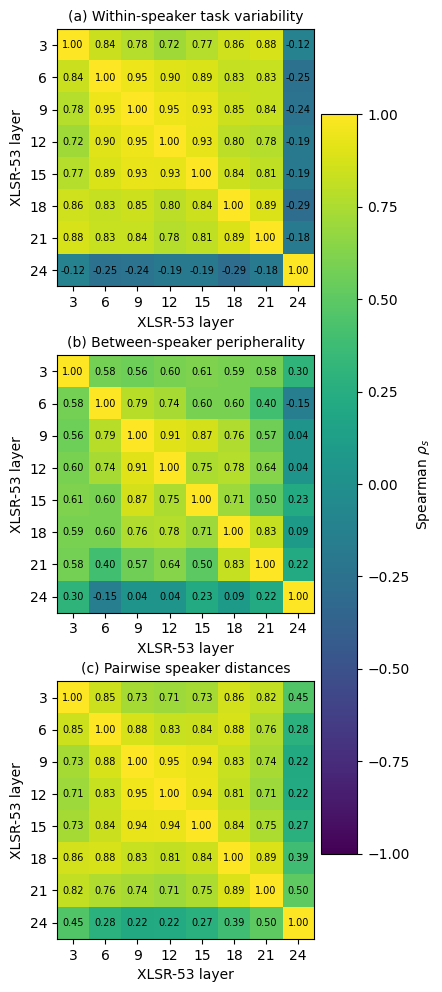

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.spatial.distance import squareform


# ------------------------------------------------------------
# 1. Within-speaker task variability
# ------------------------------------------------------------

within_layer_corr = pd.DataFrame(
    index=xlsr_layers,
    columns=xlsr_layers,
    dtype=float
)

for layer1 in xlsr_layers:
    for layer2 in xlsr_layers:

        x = (
            xlsr_speaker_within[layer1]
            .set_index("speaker_id")["mean_within_distance"]
        )

        y = (
            xlsr_speaker_within[layer2]
            .set_index("speaker_id")["mean_within_distance"]
        )

        # Align speakers
        common = x.index.intersection(y.index)

        x = x.loc[common]
        y = y.loc[common]

        within_layer_corr.loc[layer1, layer2] = spearmanr(
            x, y
        ).statistic


# ------------------------------------------------------------
# 2. Between-speaker peripherality
# ------------------------------------------------------------

between_layer_corr = pd.DataFrame(
    index=xlsr_layers,
    columns=xlsr_layers,
    dtype=float
)

for layer1 in xlsr_layers:
    for layer2 in xlsr_layers:

        x = (
            xlsr_speaker_between[layer1]
            .set_index("speaker_id")["mean_between_distance"]
        )

        y = (
            xlsr_speaker_between[layer2]
            .set_index("speaker_id")["mean_between_distance"]
        )

        # Align speakers
        common = x.index.intersection(y.index)

        x = x.loc[common]
        y = y.loc[common]

        between_layer_corr.loc[layer1, layer2] = spearmanr(
            x, y
        ).statistic


# ------------------------------------------------------------
# 3. Pairwise speaker distances (RSA)
# ------------------------------------------------------------

rsa_layer_corr = pd.DataFrame(
    index=xlsr_layers,
    columns=xlsr_layers,
    dtype=float
)

for layer1 in xlsr_layers:
    for layer2 in xlsr_layers:

        rdm1 = xlsr_rdms[layer1]
        rdm2 = xlsr_rdms[layer2]

        # Align speakers
        common = rdm1.index.intersection(rdm2.index)

        rdm1 = rdm1.loc[common, common]
        rdm2 = rdm2.loc[common, common]

        # Unique pairwise distances
        x = squareform(rdm1.values, checks=False)
        y = squareform(rdm2.values, checks=False)

        rsa_layer_corr.loc[layer1, layer2] = spearmanr(
            x, y
        ).statistic


# ------------------------------------------------------------
# Print matrices
# ------------------------------------------------------------

print("Within-speaker task variability")
display(within_layer_corr.round(2))

print("Between-speaker peripherality")
display(between_layer_corr.round(2))

print("Pairwise speaker distances")
display(rsa_layer_corr.round(2))


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3, 1,
    figsize=(4, 12)
)

panels = [
    (
        axes[0],
        within_layer_corr,
        "(a) Within-speaker task variability"
    ),
    (
        axes[1],
        between_layer_corr,
        "(b) Between-speaker peripherality"
    ),
    (
        axes[2],
        rsa_layer_corr,
        "(c) Pairwise speaker distances"
    )
]

for ax, matrix, title in panels:

    im = ax.imshow(
        matrix.values,
        vmin=-1,
        vmax=1,
        aspect="equal"
    )

    # Layer labels on both axes
    ax.set_xticks(range(len(xlsr_layers)))
    ax.set_xticklabels(xlsr_layers)

    ax.set_yticks(range(len(xlsr_layers)))
    ax.set_yticklabels(xlsr_layers)

    ax.set_xlabel("XLSR-53 layer")
    ax.set_ylabel("XLSR-53 layer")
    ax.set_title(title, fontsize=10)

    # Correlation value in every cell
    for i in range(len(xlsr_layers)):
        for j in range(len(xlsr_layers)):

            value = matrix.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )


# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(r"Spearman $\rho_s$")

plt.savefig(
    "xlsr_layer_correspondence.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()